# Nested Sampling with Unknown Covariance

This notebook implements a **Nested Sampling** algorithm for a Bayesian Gaussian model in which both the mean vector and the covariance matrix are unknown.

For observations $y_1, \dots, y_n \in \mathbb{R}^d$, the model is

$$
y_i \mid \theta, \Sigma \sim \mathcal{N}_d(\theta, \Sigma),
$$

where $\theta \in \mathbb{R}^d$ is the unknown mean and $\Sigma \in \mathbb{R}^{d \times d}$ is an unknown positive-definite covariance matrix.

The prior distribution is the conjugate **Normal-Inverse-Wishart** prior:

$$
\Sigma \sim \mathcal{IW}(\Psi_0, \nu_0), \qquad
\theta \mid \Sigma \sim \mathcal{N}_d(\mu_0, \Sigma / \kappa_0).
$$

The objective is to estimate the Bayesian evidence $Z = p(y_1, \dots, y_n)$ with Nested Sampling and compare the numerical estimate with the analytical evidence available under conjugacy. This makes the example useful both as a methodological implementation and as a benchmark for diagnosing sampling performance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import multigammaln, logsumexp
from scipy.linalg import cholesky, solve_triangular
from scipy.stats import invwishart
from tqdm.notebook import tqdm


## 1. Basic utilities

This section contains numerical helper functions and a simulator for multivariate Gaussian data. The simulator is used to create controlled examples where the true mean and covariance matrix are known.


In [2]:
def logdiffexp(a, b):
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))


def make_spd(A, jitter=1e-9):
    A = 0.5 * (A + A.T)
    return A + jitter * np.eye(A.shape[0])


def simulate_gaussian_unknown_sigma(n, d, theta_true=None, Sigma_true=None, seed=None):
    rng = np.random.default_rng(seed)
    if theta_true is None:
        theta_true = np.zeros(d)
    if Sigma_true is None:
        A = rng.normal(size=(d, d))
        Sigma_true = A @ A.T / d + 0.5 * np.eye(d)
    Y = rng.multivariate_normal(theta_true, Sigma_true, size=n)
    return Y, theta_true, Sigma_true


## 2. Normal-Inverse-Wishart prior and analytical evidence

The Normal-Inverse-Wishart prior is conjugate for a Gaussian likelihood with unknown mean and covariance. This gives closed-form posterior hyperparameters and an analytical expression for the marginal likelihood.

This analytical evidence is essential: it provides a ground-truth benchmark against which the Nested Sampling estimate can be evaluated.


In [3]:
def niw_default_hyperparams(d):
    mu0 = np.zeros(d)
    kappa0 = 1.0
    nu0 = d + 3.0
    Psi0 = np.eye(d)
    return mu0, kappa0, nu0, Psi0


def niw_posterior_params(Y, mu0, kappa0, nu0, Psi0):
    Y = np.asarray(Y)
    n, d = Y.shape
    ybar = Y.mean(axis=0)
    S = (Y - ybar).T @ (Y - ybar)

    kappa_n = kappa0 + n
    nu_n = nu0 + n
    mu_n = (kappa0 * mu0 + n * ybar) / kappa_n
    diff = (ybar - mu0).reshape(-1, 1)
    Psi_n = Psi0 + S + (kappa0 * n / kappa_n) * (diff @ diff.T)
    return mu_n, kappa_n, nu_n, make_spd(Psi_n)


def log_marginal_likelihood_niw(Y, mu0, kappa0, nu0, Psi0):
    Y = np.asarray(Y)
    n, d = Y.shape
    _, kappa_n, nu_n, Psi_n = niw_posterior_params(Y, mu0, kappa0, nu0, Psi0)

    sign0, logdet0 = np.linalg.slogdet(Psi0)
    signn, logdetn = np.linalg.slogdet(Psi_n)
    if sign0 <= 0 or signn <= 0:
        raise ValueError("Psi0 and Psi_n must be positive definite.")

    return (
        -0.5 * n * d * np.log(np.pi)
        + 0.5 * d * (np.log(kappa0) - np.log(kappa_n))
        + 0.5 * nu0 * logdet0
        - 0.5 * nu_n * logdetn
        + multigammaln(0.5 * nu_n, d)
        - multigammaln(0.5 * nu0, d)
    )


def sample_niw_prior(mu0, kappa0, nu0, Psi0, rng):
    Sigma = invwishart.rvs(df=nu0, scale=Psi0, random_state=rng)
    Sigma = np.atleast_2d(Sigma)
    theta = rng.multivariate_normal(mu0, Sigma / kappa0)
    return theta, make_spd(Sigma)


## 3. Log-density functions

The following functions evaluate the Gaussian likelihood and the Normal-Inverse-Wishart prior. All computations are performed on the log scale to improve numerical stability.


In [4]:
def log_multivariate_normal_density(x, mean, Sigma):
    x = np.asarray(x)
    mean = np.asarray(mean)
    d = mean.size
    L = cholesky(Sigma, lower=True, check_finite=False)
    z = solve_triangular(L, x - mean, lower=True, check_finite=False)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2*np.pi) + logdet + z @ z)


def log_prior_niw(theta, Sigma, mu0, kappa0, nu0, Psi0):
    return invwishart.logpdf(Sigma, df=nu0, scale=Psi0) + log_multivariate_normal_density(theta, mu0, Sigma / kappa0)


def log_likelihood_gaussian(Y, theta, Sigma):
    Y = np.asarray(Y)
    n, d = Y.shape
    L = cholesky(Sigma, lower=True, check_finite=False)
    Z = solve_triangular(L, (Y - theta).T, lower=True, check_finite=False)
    quad = np.sum(Z**2)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (n * d * np.log(2*np.pi) + n * logdet + quad)


## 4. Cholesky parametrisation of the covariance matrix

Sampling directly over covariance matrices is difficult because proposals must remain positive definite. To avoid invalid proposals, the covariance is represented through its Cholesky factor:

$$
\Sigma = LL^T,
$$

where $L$ is lower triangular with positive diagonal entries.

The diagonal entries of $L$ are stored on the log scale. This converts the constrained covariance problem into an unconstrained Euclidean parametrisation, while the Jacobian correction preserves the correct target density.


In [5]:
def sigma_to_cholesky_params(Sigma):
    L = cholesky(Sigma, lower=True, check_finite=False)
    d = Sigma.shape[0]
    params = []
    for i in range(d):
        for j in range(i + 1):
            params.append(np.log(L[i, i]) if i == j else L[i, j])
    return np.array(params)


def cholesky_params_to_sigma(params, d):
    L = np.zeros((d, d))
    k = 0
    for i in range(d):
        for j in range(i + 1):
            L[i, j] = np.exp(params[k]) if i == j else params[k]
            k += 1
    return make_spd(L @ L.T), L


def log_cholesky_jacobian_from_L(L):
    d = L.shape[0]
    log_diag = np.log(np.diag(L))
    return d * np.log(2.0) + sum((d + 1 - i) * log_diag[i] for i in range(d))


def pack_state(theta, Sigma):
    return np.concatenate([theta, sigma_to_cholesky_params(Sigma)])


def unpack_state(u, d):
    theta = u[:d]
    Sigma, L = cholesky_params_to_sigma(u[d:], d)
    return theta, Sigma, L


def log_prior_unconstrained(u, d, mu0, kappa0, nu0, Psi0):
    theta, Sigma, L = unpack_state(u, d)
    return log_prior_niw(theta, Sigma, mu0, kappa0, nu0, Psi0) + log_cholesky_jacobian_from_L(L)


## 5. Constrained MCMC kernel

Nested Sampling requires drawing replacement particles from the prior subject to a likelihood constraint. Since exact constrained sampling is not available here, the notebook uses a Metropolis-Hastings kernel targeting the prior restricted to the region where the likelihood is above the current threshold.

This step is the main computational bottleneck and the main source of approximation error. Its quality is therefore assessed later through acceptance rates and repeated-run diagnostics.


In [6]:
def constrained_mcmc_niw(
    Y,
    start_theta,
    start_Sigma,
    logL_min,
    mu0,
    kappa0,
    nu0,
    Psi0,
    n_steps=200,
    step_theta=0.15,
    step_chol=0.05,
    seed=None,
    return_chain=False,
):
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    u = pack_state(start_theta, start_Sigma)
    n_chol = d * (d + 1) // 2
    proposal_scales = np.concatenate([step_theta * np.ones(d), step_chol * np.ones(n_chol)])

    theta, Sigma, _ = unpack_state(u, d)
    current_logL = log_likelihood_gaussian(Y, theta, Sigma)
    if current_logL <= logL_min:
        raise ValueError("Starting point does not satisfy the likelihood constraint.")
    current_logprior_u = log_prior_unconstrained(u, d, mu0, kappa0, nu0, Psi0)

    accepted = 0
    chain_theta = []
    chain_logL = []

    for _ in range(n_steps):
        u_prop = u + rng.normal(scale=proposal_scales)
        theta_prop, Sigma_prop, _ = unpack_state(u_prop, d)
        logL_prop = log_likelihood_gaussian(Y, theta_prop, Sigma_prop)

        if logL_prop > logL_min:
            logprior_prop_u = log_prior_unconstrained(u_prop, d, mu0, kappa0, nu0, Psi0)
            if np.log(rng.uniform()) < logprior_prop_u - current_logprior_u:
                u = u_prop
                current_logL = logL_prop
                current_logprior_u = logprior_prop_u
                accepted += 1

        if return_chain:
            theta_now, _, _ = unpack_state(u, d)
            chain_theta.append(theta_now.copy())
            chain_logL.append(current_logL)

    theta, Sigma, _ = unpack_state(u, d)
    out = {
        "theta": theta,
        "Sigma": Sigma,
        "logL": current_logL,
        "acceptance_rate": accepted / max(n_steps, 1),
    }
    if return_chain:
        out["chain_theta"] = np.array(chain_theta)
        out["chain_logL"] = np.array(chain_logL)
    return out


## 6. Nested Sampling algorithm on $(\theta, \Sigma)$

Each live particle is a pair $(\theta, \Sigma)$. At every iteration, the particle with the lowest likelihood is removed, the prior mass is compressed, and a new particle satisfying the likelihood constraint is generated with the constrained MCMC kernel.

The algorithm returns the estimated log evidence, the sequence of likelihood thresholds, the compression path, and diagnostic information about the constrained MCMC replacement steps.


In [7]:
def nested_sampling_gaussian_unknown_sigma(
    Y,
    N_live=50,
    max_iter=500,
    mu0=None,
    kappa0=None,
    nu0=None,
    Psi0=None,
    mcmc_steps=200,
    step_theta=0.15,
    step_chol=0.05,
    seed=None,
    use_random_shrinkage=True,
    return_path=False,
):
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    if mu0 is None or kappa0 is None or nu0 is None or Psi0 is None:
        mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)

    live_theta, live_Sigma, live_logL = [], [], []
    for _ in range(N_live):
        th, Sig = sample_niw_prior(mu0, kappa0, nu0, Psi0, rng)
        live_theta.append(th)
        live_Sigma.append(Sig)
        live_logL.append(log_likelihood_gaussian(Y, th, Sig))

    live_theta = np.array(live_theta)
    live_Sigma = np.array(live_Sigma)
    live_logL = np.array(live_logL)

    logX_prev = 0.0
    logZ_terms = []
    logZ_partial = []
    logX_path = [logX_prev]
    dead_logL = []
    acceptance_rates = []

    for _ in range(max_iter):
        worst = int(np.argmin(live_logL))
        logL_min = float(live_logL[worst])

        log_t = np.log(rng.uniform()) / N_live if use_random_shrinkage else -1.0 / N_live
        logX_new = logX_prev + log_t
        log_width = logdiffexp(logX_prev, logX_new)

        logZ_terms.append(log_width + logL_min)
        dead_logL.append(logL_min)
        logZ_partial.append(logsumexp(logZ_terms))
        logX_path.append(logX_new)

        survivors = [j for j in range(N_live) if j != worst]
        start = int(rng.choice(survivors))
        new = constrained_mcmc_niw(
            Y,
            live_theta[start],
            live_Sigma[start],
            logL_min,
            mu0,
            kappa0,
            nu0,
            Psi0,
            n_steps=mcmc_steps,
            step_theta=step_theta,
            step_chol=step_chol,
            seed=int(rng.integers(0, 10**9)),
        )

        live_theta[worst] = new["theta"]
        live_Sigma[worst] = new["Sigma"]
        live_logL[worst] = new["logL"]
        acceptance_rates.append(new["acceptance_rate"])
        logX_prev = logX_new

    logZ_live = logX_prev + logsumexp(live_logL) - np.log(N_live)
    logZ_hat = logsumexp(logZ_terms + [logZ_live])

    out = {
        "logZ_hat": logZ_hat,
        "live_theta": live_theta,
        "live_Sigma": live_Sigma,
        "live_logL": live_logL,
        "acceptance_rates": np.array(acceptance_rates),
        "mean_acceptance_rate": float(np.mean(acceptance_rates)),
    }
    if return_path:
        out.update({
            "logZ_partial": np.array(logZ_partial),
            "Xs": np.exp(np.array(logX_path)),
            "logX_path": np.array(logX_path),
            "dead_logL": np.array(dead_logL),
        })
    return out


## 7. Effective Sample Size diagnostics

These functions provide basic autocorrelation and effective sample size diagnostics. They are useful for assessing whether the constrained MCMC kernel explores the constrained region efficiently.


In [8]:
def autocorrelation_1d(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    if max_lag is None:
        max_lag = min(n // 2, 200)
    denom = np.dot(x, x)
    if denom == 0:
        return np.ones(max_lag + 1)
    acf = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        acf[lag] = np.dot(x[:n-lag], x[lag:]) / denom
    return acf


def ess_1d(x, max_lag=None):
    acf = autocorrelation_1d(x, max_lag=max_lag)
    positive = acf[1:]
    cutoff = len(positive)
    for k, val in enumerate(positive):
        if val < 0:
            cutoff = k
            break
    tau = 1.0 + 2.0 * np.sum(positive[:cutoff])
    return len(x) / max(tau, 1e-12)


def ess_by_column(X, max_lag=None):
    X = np.asarray(X)
    if X.ndim == 1:
        return ess_1d(X, max_lag=max_lag)
    return np.array([ess_1d(X[:, j], max_lag=max_lag) for j in range(X.shape[1])])


## 8. Quick benchmark run

The following cell runs a small two-dimensional example. Because the analytical evidence is available, the Nested Sampling estimate can be compared directly to the exact value.


In [9]:
n = 25
d = 2
Y, theta_true, Sigma_true = simulate_gaussian_unknown_sigma(n, d, seed=123)

mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)
true_logZ = log_marginal_likelihood_niw(Y, mu0, kappa0, nu0, Psi0)

out = nested_sampling_gaussian_unknown_sigma(
    Y,
    N_live=40,
    max_iter=300,
    mu0=mu0,
    kappa0=kappa0,
    nu0=nu0,
    Psi0=Psi0,
    mcmc_steps=150,
    step_theta=0.12,
    step_chol=0.04,
    seed=2024,
    return_path=True,
)

print("True log evidence:", true_logZ)
print("NS log evidence estimate:", out["logZ_hat"])
print("Error:", out["logZ_hat"] - true_logZ)
print("Mean MCMC acceptance rate:", out["mean_acceptance_rate"])


True log evidence: -75.20731923382947
NS log evidence estimate: -74.96141421304718
Error: 0.24590502078228837
Mean MCMC acceptance rate: 0.7075555555555555


## 9. Visual diagnostics

The plots below are designed for both debugging and presentation. They show evidence convergence, likelihood compression, and constrained-MCMC acceptance behavior.


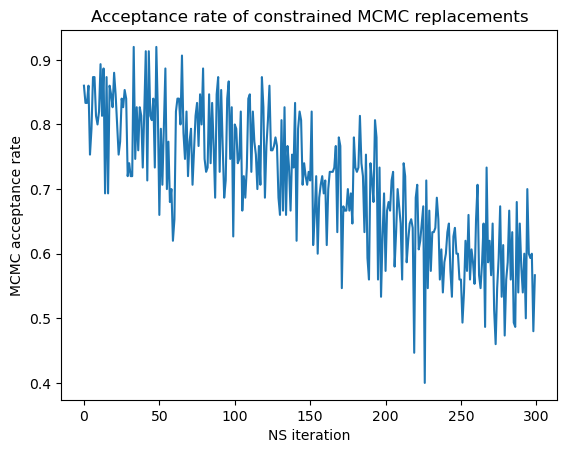

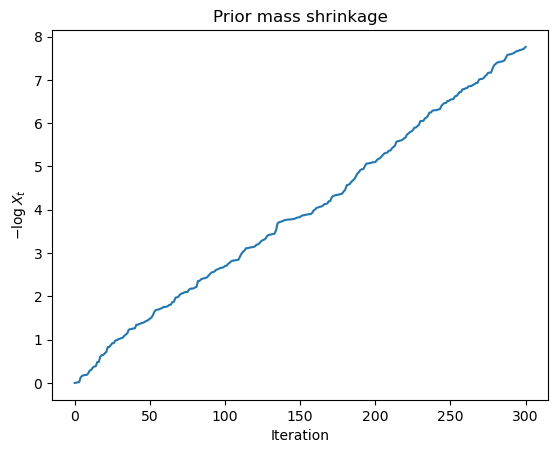

In [10]:
def plot_q4_convergence(Y, N_live=40, max_iter=300, mcmc_steps=150, seed=1):
    n, d = Y.shape
    mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)
    true_val = log_marginal_likelihood_niw(Y, mu0, kappa0, nu0, Psi0)
    out = nested_sampling_gaussian_unknown_sigma(
        Y,
        N_live=N_live,
        max_iter=max_iter,
        mu0=mu0,
        kappa0=kappa0,
        nu0=nu0,
        Psi0=Psi0,
        mcmc_steps=mcmc_steps,
        seed=seed,
        return_path=True,
    )
    plt.figure()
    plt.plot(out["logZ_partial"], label="Running estimate")
    plt.axhline(true_val, linestyle="--", linewidth=1.5, label="Analytical log evidence")
    plt.xlabel("Iteration")
    plt.ylabel("Log evidence estimate")
    plt.title(f"Q4 NS convergence, N_live={N_live}")
    plt.legend()
    plt.show()
    return out


def plot_q4_acceptance_rates(out):
    plt.figure()
    plt.plot(out["acceptance_rates"])
    plt.xlabel("NS iteration")
    plt.ylabel("MCMC acceptance rate")
    plt.title("Acceptance rate of constrained MCMC replacements")
    plt.show()


def plot_q4_logX(out):
    plt.figure()
    plt.plot(-out["logX_path"])
    plt.xlabel("Iteration")
    plt.ylabel(r"$-\log X_t$")
    plt.title("Prior mass shrinkage")
    plt.show()

plot_q4_acceptance_rates(out)
plot_q4_logX(out)


## 10. Standalone constrained-MCMC diagnostic

This diagnostic isolates the constrained MCMC replacement step. It helps determine whether poor Nested Sampling performance comes from insufficient mixing inside the likelihood-constrained region.


Constraint logL_min: -175.3523740920541
Acceptance rate: 0.735
ESS(theta): [15.59679039 15.32176969]
ESS(logL): 42.08219497085956


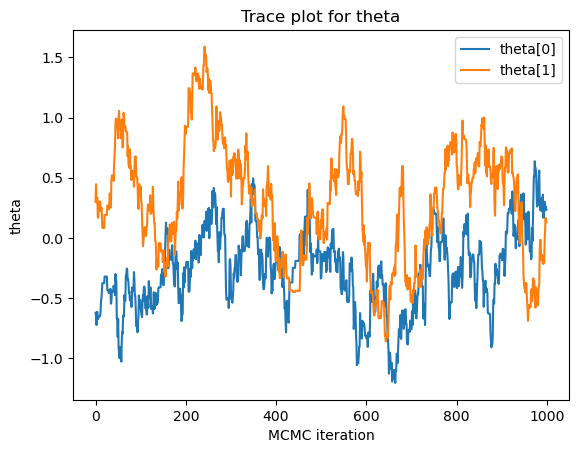

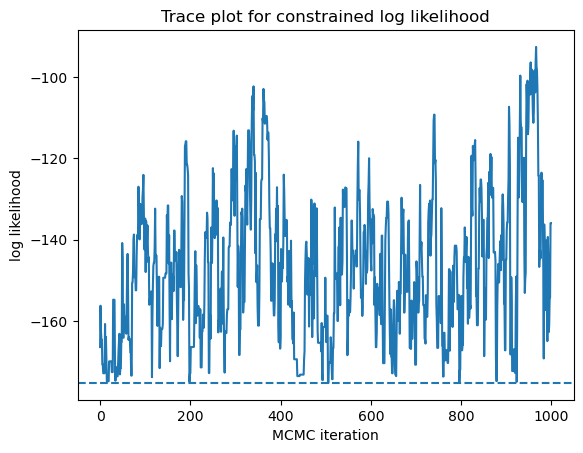

In [11]:
def run_standalone_q4_mcmc_diagnostic(
    Y,
    quantile=0.5,
    n_prior_draws=1000,
    n_steps=2000,
    step_theta=0.12,
    step_chol=0.04,
    seed=123,
):
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)

    prior_thetas, prior_Sigmas, prior_logL = [], [], []
    for _ in range(n_prior_draws):
        th, Sig = sample_niw_prior(mu0, kappa0, nu0, Psi0, rng)
        prior_thetas.append(th)
        prior_Sigmas.append(Sig)
        prior_logL.append(log_likelihood_gaussian(Y, th, Sig))
    prior_logL = np.array(prior_logL)
    logL_min = float(np.quantile(prior_logL, quantile))

    valid = np.where(prior_logL > logL_min)[0]
    start = int(rng.choice(valid))
    out = constrained_mcmc_niw(
        Y,
        prior_thetas[start],
        prior_Sigmas[start],
        logL_min,
        mu0,
        kappa0,
        nu0,
        Psi0,
        n_steps=n_steps,
        step_theta=step_theta,
        step_chol=step_chol,
        seed=int(rng.integers(0, 10**9)),
        return_chain=True,
    )

    theta_ess = ess_by_column(out["chain_theta"])
    logL_ess = ess_1d(out["chain_logL"])

    print("Constraint logL_min:", logL_min)
    print("Acceptance rate:", out["acceptance_rate"])
    print("ESS(theta):", theta_ess)
    print("ESS(logL):", logL_ess)

    plt.figure()
    for j in range(d):
        plt.plot(out["chain_theta"][:, j], label=f"theta[{j}]")
    plt.xlabel("MCMC iteration")
    plt.ylabel("theta")
    plt.title("Trace plot for theta")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(out["chain_logL"])
    plt.axhline(logL_min, linestyle="--", linewidth=1.5)
    plt.xlabel("MCMC iteration")
    plt.ylabel("log likelihood")
    plt.title("Trace plot for constrained log likelihood")
    plt.show()

    return out


diag = run_standalone_q4_mcmc_diagnostic(Y, n_steps=1000)


## 11. Repeated Nested Sampling runs

A single Nested Sampling run is not enough to evaluate performance. Repeating the algorithm with different random seeds allows us to estimate bias, variability, RMSE, and stability of the log-evidence estimate.


In [12]:
def assess_q4_ns_single_dataset(
    Y,
    N_live_list=(20, 40, 80),
    n_rep=10,
    max_iter=300,
    mcmc_steps=150,
    seed=1234,
):
    n, d = Y.shape
    mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)
    true_logZ = log_marginal_likelihood_niw(Y, mu0, kappa0, nu0, Psi0)
    rng = np.random.default_rng(seed)
    results = {}

    total = len(N_live_list) * n_rep
    with tqdm(total=total, desc="Q4 repeated NS") as pbar:
        for N_live in N_live_list:
            estimates = []
            acc_rates = []
            for _ in range(n_rep):
                out = nested_sampling_gaussian_unknown_sigma(
                    Y,
                    N_live=N_live,
                    max_iter=max_iter,
                    mu0=mu0,
                    kappa0=kappa0,
                    nu0=nu0,
                    Psi0=Psi0,
                    mcmc_steps=mcmc_steps,
                    seed=int(rng.integers(0, 10**9)),
                )
                estimates.append(out["logZ_hat"])
                acc_rates.append(out["mean_acceptance_rate"])
                pbar.update(1)

            estimates = np.array(estimates)
            errors = estimates - true_logZ
            results[N_live] = {
                "true_logZ": true_logZ,
                "mean_logZ_hat": np.mean(estimates),
                "std_logZ_hat": np.std(estimates, ddof=1) if len(estimates) > 1 else 0.0,
                "bias_logZ": np.mean(errors),
                "rmse_logZ": np.sqrt(np.mean(errors**2)),
                "mean_acceptance_rate": np.mean(acc_rates),
                "estimates": estimates,
                "errors": errors,
                "acceptance_rates": np.array(acc_rates),
            }
    return results


def plot_q4_boxplots(results):
    N_vals = sorted(results.keys())
    data = [results[N]["estimates"] for N in N_vals]
    true_val = results[N_vals[0]]["true_logZ"]
    plt.figure()
    plt.boxplot(data, labels=[str(N) for N in N_vals])
    plt.axhline(true_val, linestyle="--", linewidth=1.5, label="Analytical log evidence")
    plt.xlabel("Number of live points")
    plt.ylabel("Estimated log evidence")
    plt.title("Q4 NS estimates across repetitions")
    plt.legend()
    plt.show()


def plot_q4_rmse(results):
    N_vals = sorted(results.keys())
    rmse_vals = [results[N]["rmse_logZ"] for N in N_vals]
    plt.figure()
    plt.plot(N_vals, rmse_vals, marker="o")
    plt.xlabel("Number of live points")
    plt.ylabel("RMSE of log evidence")
    plt.title("Q4 RMSE vs number of live points")
    plt.show()


In [13]:
from matplotlib.patches import Ellipse


def sample_niw_posterior(Y, n_samples=1000, seed=123):
    """Draw exact posterior samples from the NIW posterior benchmark."""
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)
    mu_n, kappa_n, nu_n, Psi_n = niw_posterior_params(Y, mu0, kappa0, nu0, Psi0)

    theta_samples = np.zeros((n_samples, d))
    Sigma_samples = np.zeros((n_samples, d, d))
    for s in range(n_samples):
        Sigma_s = invwishart.rvs(df=nu_n, scale=Psi_n, random_state=rng)
        theta_s = rng.multivariate_normal(mu_n, Sigma_s / kappa_n)
        theta_samples[s] = theta_s
        Sigma_samples[s] = Sigma_s
    return theta_samples, Sigma_samples


def add_cov_ellipse(ax, mean, cov, level=0.95, **kwargs):
    """Add a 2D Gaussian covariance ellipse to an existing axis."""
    if cov.shape != (2, 2):
        raise ValueError("Covariance ellipse is only defined for d=2.")
    # chi-square quantile with 2 degrees of freedom at 95% is approximately 5.991
    chi2_value = 5.991 if abs(level - 0.95) < 1e-12 else -2.0 * np.log(1.0 - level)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(chi2_value * vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)
    return ell


def plot_q4_data_posterior_geometry(Y, theta_true=None, Sigma_true=None, seed=123):
    """Presentation plot: data cloud + exact posterior benchmark geometry for d=2."""
    n, d = Y.shape
    if d != 2:
        raise ValueError("This visual explanation is designed for d=2.")

    theta_samples, Sigma_samples = sample_niw_posterior(Y, n_samples=1500, seed=seed)
    posterior_mean = theta_samples.mean(axis=0)
    posterior_cov_theta = np.cov(theta_samples.T)
    posterior_mean_Sigma = Sigma_samples.mean(axis=0)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(Y[:, 0], Y[:, 1], alpha=0.7, label="observations")
    ax.scatter(theta_samples[:300, 0], theta_samples[:300, 1], s=10, alpha=0.20, label="posterior draws of theta")
    ax.scatter([posterior_mean[0]], [posterior_mean[1]], marker="x", s=90, label="posterior mean of theta")
    ax.scatter([Y[:, 0].mean()], [Y[:, 1].mean()], marker="+", s=120, label="sample mean")

    if theta_true is not None:
        ax.scatter([theta_true[0]], [theta_true[1]], marker="*", s=160, label="true theta")
    if Sigma_true is not None:
        add_cov_ellipse(ax, theta_true if theta_true is not None else Y.mean(axis=0), Sigma_true, linewidth=1.5, label="true covariance ellipse")

    add_cov_ellipse(ax, posterior_mean, posterior_cov_theta, linewidth=2.0, label="95% posterior ellipse for theta")
    add_cov_ellipse(ax, posterior_mean, posterior_mean_Sigma, linewidth=1.5, linestyle="--", label="mean posterior Sigma ellipse")

    ax.set_title("Q4 geometry: data, posterior mean, and covariance")
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")
    ax.axis("equal")
    ax.legend(loc="best")
    plt.show()


def summarize_q4_results_table(results):
    """Small table to paste into slides."""
    rows = []
    for N_live in sorted(results):
        r = results[N_live]
        rows.append({
            "N_live": N_live,
            "mean_logZ_hat": r["mean_logZ_hat"],
            "std_logZ_hat": r["std_logZ_hat"],
            "bias_logZ": r["bias_logZ"],
            "rmse_logZ": r["rmse_logZ"],
            "mean_acceptance_rate": r["mean_acceptance_rate"],
        })
    return rows


def print_q4_results_table(results):
    rows = summarize_q4_results_table(results)
    header = f"{'N_live':>8} | {'mean logZ':>10} | {'sd':>8} | {'bias':>8} | {'RMSE':>8} | {'acc.':>8}"
    print(header)
    print("-" * len(header))
    for r in rows:
        print(f"{r['N_live']:8d} | {r['mean_logZ_hat']:10.3f} | {r['std_logZ_hat']:8.3f} | {r['bias_logZ']:8.3f} | {r['rmse_logZ']:8.3f} | {r['mean_acceptance_rate']:8.3f}")


def plot_q4_error_distribution(results):
    """Plot estimation error rather than raw estimates; this is easier to explain on slides."""
    N_vals = sorted(results.keys())
    data = [results[N]["errors"] for N in N_vals]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data, labels=[str(N) for N in N_vals])
    plt.axhline(0.0, linestyle="--", linewidth=1.5)
    plt.xlabel("Number of live particles")
    plt.ylabel(r"$\widehat{\log Z} - \log Z_{exact}$")
    plt.title("Evidence error across repeated NS runs")
    plt.show()


def plot_q4_likelihood_compression(out):
    """Core NS diagnostic: likelihood should increase as prior mass shrinks."""
    plt.figure(figsize=(7, 4.5))
    plt.plot(-out["logX_path"][1:], out["dead_logL"])
    plt.xlabel(r"$-\log X_t$  (compression of prior mass)")
    plt.ylabel("discarded log likelihood")
    plt.title("Nested Sampling path: likelihood increases as prior mass shrinks")
    plt.show()


## 12. Presentation example: two-dimensional geometry

This example is designed for slides. In dimension $d=2$, the data cloud, posterior draws of the mean, and covariance ellipses can be visualized directly. This makes it easier to explain what the algorithm is estimating.


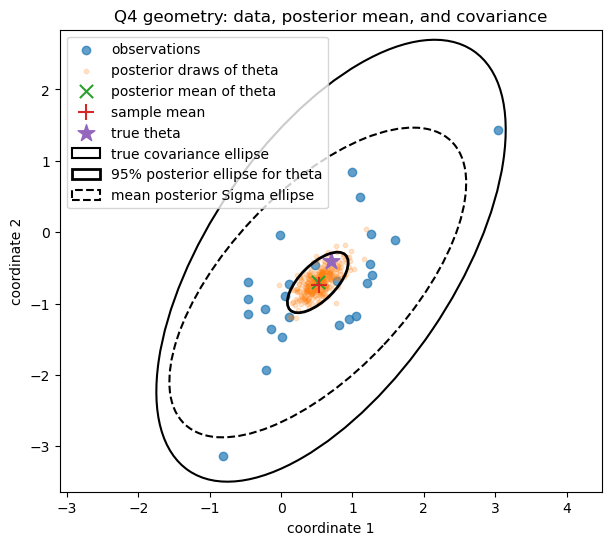

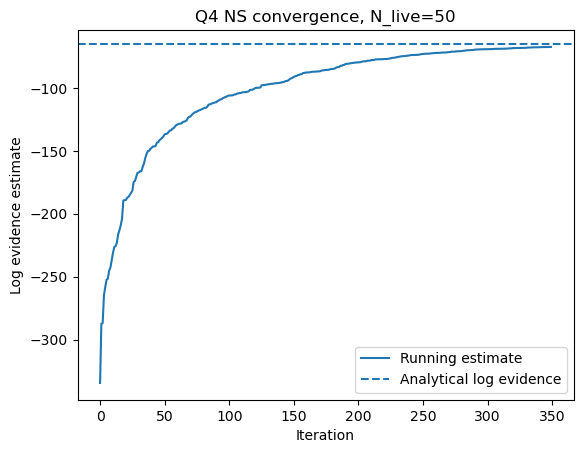

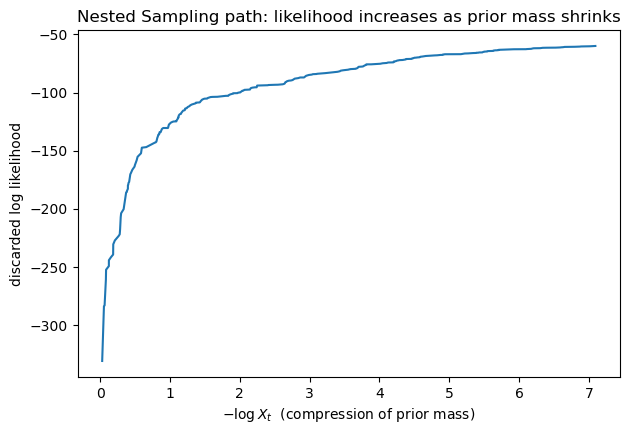

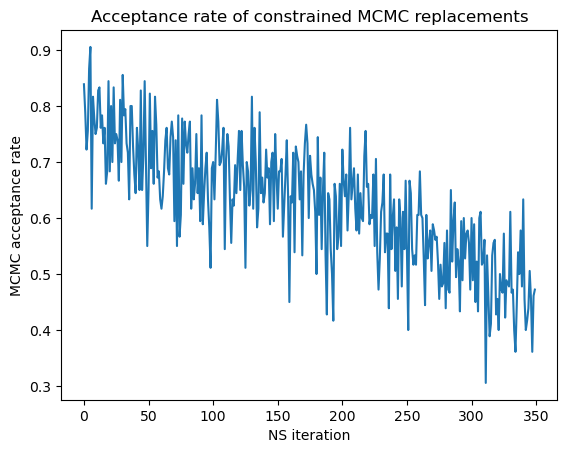

In [14]:

n_A, d_A = 25, 2
Sigma_A = np.array([[1.0, 0.75], [0.75, 1.6]])
theta_A = np.array([0.7, -0.4])
Y_A, theta_true_A, Sigma_true_A = simulate_gaussian_unknown_sigma(
    n_A, d_A, theta_true=theta_A, Sigma_true=Sigma_A, seed=42
)

plot_q4_data_posterior_geometry(Y_A, theta_true_A, Sigma_true_A, seed=42)

out_A = plot_q4_convergence(Y_A, N_live=50, max_iter=350, mcmc_steps=180, seed=7)
plot_q4_likelihood_compression(out_A)
plot_q4_acceptance_rates(out_A)


Q4 repeated NS:   0%|          | 0/15 [00:00<?, ?it/s]

  N_live |  mean logZ |       sd |     bias |     RMSE |     acc.
-----------------------------------------------------------------
      20 |    -64.958 |    0.382 |    0.462 |    0.575 |    0.430
      40 |    -65.248 |    0.793 |    0.172 |    0.730 |    0.623
      80 |    -66.068 |    1.599 |   -0.648 |    1.570 |    0.703


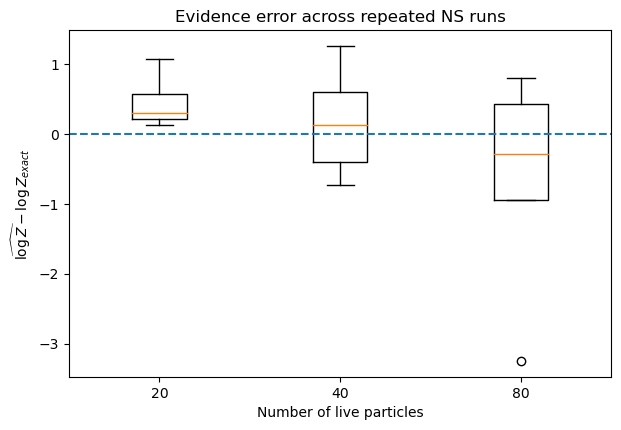

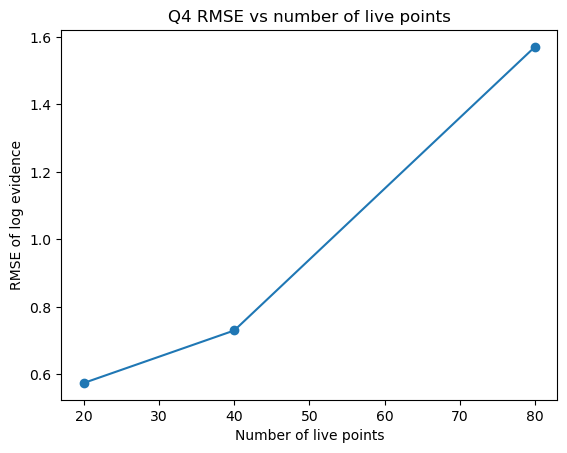

In [15]:

results_A = assess_q4_ns_single_dataset(
    Y_A,
    N_live_list=(20, 40, 80),
    n_rep=5,
    max_iter=300,
    mcmc_steps=150,
    seed=99,
)

print_q4_results_table(results_A)
plot_q4_error_distribution(results_A)
plot_q4_rmse(results_A)


## 13. Suggested speaking points for the Q4 slide

**Main message.** The known-covariance Gaussian model can be extended to the unknown-covariance case by placing a Normal-Inverse-Wishart prior on $(\theta, \Sigma)$. This keeps the model analytically tractable and gives an exact evidence benchmark.

**Algorithmic change.** A live particle is no longer just a mean vector. It is now the pair $(\theta, \Sigma)$. Since exact sampling from the likelihood-constrained prior is difficult, each replacement particle is generated with a Metropolis-Hastings chain restricted to the region $L(\theta, \Sigma) > \ell$.

**Numerical strategy.** The covariance matrix is parametrised through its Cholesky factor. This guarantees positive-definite covariance proposals and makes the MCMC step easier to implement.

**Performance message.** The method works well as a proof of concept in small dimensions, but the constrained MCMC step becomes harder as $d$ increases. The covariance matrix alone has $d(d+1)/2$ free parameters, so dimensionality grows quickly.

**Presentation takeaway.** This example illustrates both the strength of Nested Sampling—direct evidence estimation—and its practical challenge: the replacement kernel must mix efficiently inside increasingly small likelihood-constrained regions.


## 14. Final performance assessment

This final section is intended for a GitHub notebook and for presentation material. It turns the implementation into an empirical study by evaluating three questions:

1. **Accuracy:** How close is the Nested Sampling estimate $\widehat{\log Z}$ to the analytical log evidence?
2. **Stability:** How much does the estimate vary across repeated runs with different random seeds?
3. **Scalability:** How does performance change when the dimension $d$ increases?

For a presentation, the most convincing performance slide is usually a compact table reporting the exact log evidence, the average NS estimate, the bias, the RMSE, the standard deviation across runs, and the mean MCMC acceptance rate.


In [16]:
def assess_q4_performance_summary(results):
    """Return a clean performance table from repeated Nested Sampling runs."""
    rows = []
    for N_live in sorted(results):
        r = results[N_live]
        rows.append({
            "N_live": N_live,
            "exact_logZ": r["true_logZ"],
            "mean_NS_logZ": r["mean_logZ_hat"],
            "bias": r["bias_logZ"],
            "RMSE": r["rmse_logZ"],
            "std_across_runs": r["std_logZ_hat"],
            "mean_acceptance_rate": r["mean_acceptance_rate"],
        })
    return rows


def print_q4_performance_summary(results):
    """Print a presentation-ready summary table."""
    rows = assess_q4_performance_summary(results)
    header = (
        f"{'N_live':>8} | {'exact logZ':>11} | {'mean NS':>10} | "
        f"{'bias':>9} | {'RMSE':>9} | {'sd':>9} | {'acc.':>7}"
    )
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['N_live']:8d} | {r['exact_logZ']:11.3f} | {r['mean_NS_logZ']:10.3f} | "
            f"{r['bias']:9.3f} | {r['RMSE']:9.3f} | {r['std_across_runs']:9.3f} | "
            f"{r['mean_acceptance_rate']:7.3f}"
        )


### 14.1 Dimensional scaling experiment

The main limitation to highlight is the growth of the parameter space. For a $d$-dimensional Gaussian model, the total number of unknown parameters is

$$
\underbrace{d}_{\theta} + \underbrace{\frac{d(d+1)}{2}}_{\Sigma}.
$$

This means that increasing $d$ from 2 to 10 increases the number of unknown parameters from 5 to 65. The following helper function runs the same benchmark for several dimensions and reports how the estimation error, runtime, and acceptance rate change.


In [17]:
import time


def number_of_unknown_parameters(d):
    """Number of free parameters in (theta, Sigma) for dimension d."""
    return d + d * (d + 1) // 2


def run_dimension_scaling_experiment(
    dimensions=(2, 3, 5),
    n=25,
    N_live=40,
    max_iter=250,
    mcmc_steps=120,
    seed=2025,
):
    """
    Benchmark Nested Sampling across dimensions.

    The default settings are intentionally moderate so that the experiment remains
    suitable for a live notebook demonstration. Increase N_live, max_iter, and
    mcmc_steps for a more serious numerical study.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for d in dimensions:
        Y, theta_true, Sigma_true = simulate_gaussian_unknown_sigma(
            n=n,
            d=d,
            seed=int(rng.integers(0, 10**9)),
        )
        mu0, kappa0, nu0, Psi0 = niw_default_hyperparams(d)
        exact_logZ = log_marginal_likelihood_niw(Y, mu0, kappa0, nu0, Psi0)

        start = time.perf_counter()
        out = nested_sampling_gaussian_unknown_sigma(
            Y,
            N_live=N_live,
            max_iter=max_iter,
            mu0=mu0,
            kappa0=kappa0,
            nu0=nu0,
            Psi0=Psi0,
            mcmc_steps=mcmc_steps,
            seed=int(rng.integers(0, 10**9)),
        )
        runtime = time.perf_counter() - start

        rows.append({
            "d": d,
            "n_parameters": number_of_unknown_parameters(d),
            "exact_logZ": exact_logZ,
            "NS_logZ": out["logZ_hat"],
            "error": out["logZ_hat"] - exact_logZ,
            "abs_error": abs(out["logZ_hat"] - exact_logZ),
            "mean_acceptance_rate": out["mean_acceptance_rate"],
            "runtime_seconds": runtime,
        })

    return rows


def print_dimension_scaling_table(rows):
    """Print a compact table for the dimensional scaling benchmark."""
    header = (
        f"{'d':>3} | {'params':>6} | {'exact logZ':>11} | {'NS logZ':>10} | "
        f"{'error':>9} | {'abs err':>9} | {'acc.':>7} | {'time (s)':>8}"
    )
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['d']:3d} | {r['n_parameters']:6d} | {r['exact_logZ']:11.3f} | "
            f"{r['NS_logZ']:10.3f} | {r['error']:9.3f} | {r['abs_error']:9.3f} | "
            f"{r['mean_acceptance_rate']:7.3f} | {r['runtime_seconds']:8.2f}"
        )


def plot_dimension_scaling(rows):
    """Visualize how error and runtime evolve with dimension."""
    dims = [r["d"] for r in rows]
    abs_errors = [r["abs_error"] for r in rows]
    runtimes = [r["runtime_seconds"] for r in rows]
    acceptances = [r["mean_acceptance_rate"] for r in rows]

    plt.figure(figsize=(7, 4.5))
    plt.plot(dims, abs_errors, marker="o")
    plt.xlabel("Dimension d")
    plt.ylabel(r"$|\widehat{\log Z} - \log Z_{exact}|$")
    plt.title("Evidence error as dimension increases")
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(dims, runtimes, marker="o")
    plt.xlabel("Dimension d")
    plt.ylabel("Runtime in seconds")
    plt.title("Computational cost as dimension increases")
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(dims, acceptances, marker="o")
    plt.xlabel("Dimension d")
    plt.ylabel("Mean MCMC acceptance rate")
    plt.title("Constrained-MCMC acceptance as dimension increases")
    plt.show()


  d | params |  exact logZ |    NS logZ |     error |   abs err |    acc. | time (s)
------------------------------------------------------------------------------------
  2 |      5 |    -100.786 |   -103.147 |    -2.362 |     2.362 |   0.747 |     5.44
  3 |      9 |     -89.738 |    -91.607 |    -1.869 |     1.869 |   0.553 |     5.07
  5 |     20 |    -202.196 |   -275.888 |   -73.692 |    73.692 |   0.402 |     5.28
 10 |     65 |    -500.036 |  -1620.681 | -1120.644 |  1120.644 |   0.037 |     4.21


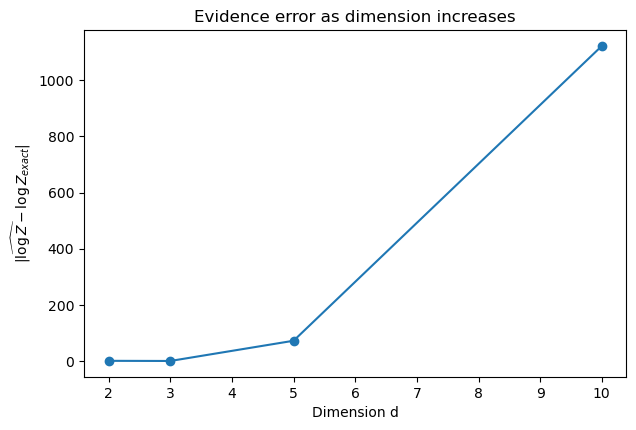

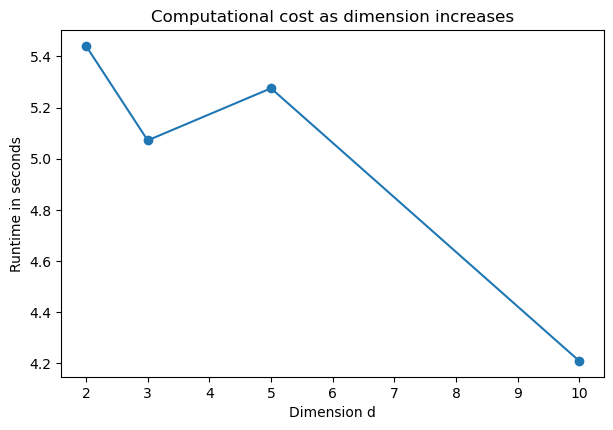

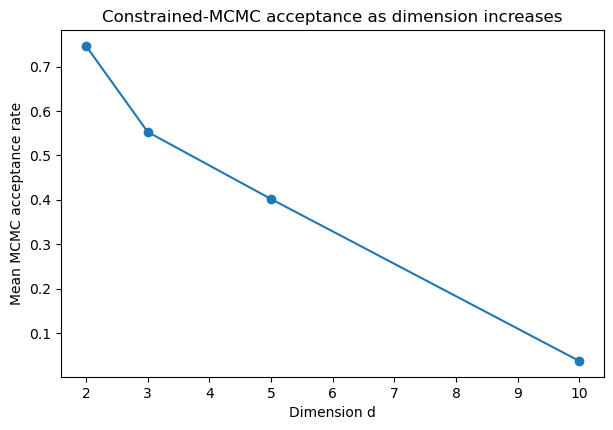

In [20]:

dimension_rows = run_dimension_scaling_experiment(
     dimensions=(2, 3, 5, 10),
     n=25,
     N_live=40,
     max_iter=250,
   mcmc_steps=120,
     seed=2025,
 )
print_dimension_scaling_table(dimension_rows)
plot_dimension_scaling(dimension_rows)


## 15. Final conclusion

This notebook shows that Nested Sampling can be extended from a Gaussian model with known covariance to a model where both the mean vector and covariance matrix are unknown. The Normal-Inverse-Wishart prior makes the problem especially useful for validation because the exact evidence is available.

The main empirical conclusion is that the method is reliable in low-dimensional settings when the constrained MCMC kernel mixes well. However, performance depends increasingly on proposal design as the dimension grows, because the covariance matrix introduces $d(d+1)/2$ additional parameters.

For a GitHub project, the notebook demonstrates a complete Bayesian workflow: model specification, prior construction, numerical implementation, analytical benchmarking, diagnostics, and performance assessment.
